# Preprocess Dosage Sensitivity Region and Gene Data
* Dosage sensitivity data from [ClinGen](https://search.clinicalgenome.org/kb/downloads)
* Used the Archived 2024-12-20 dosage sensitivity [gene](https://ftp.clinicalgenome.org/archive/20241220/ClinGen_haploinsufficiency_gene_GRCh38.bed) and [region](https://ftp.clinicalgenome.org/archive/20241220/ClinGen_haploinsufficiency_gene_GRCh38.bed) files with haploinsufficiency (HI) and triplosensitivity (TS) scores equal to 3 ("sufficient evidence" tier)

In [100]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import plotly.graph_objects as go

In [2]:
dosage_gene_path = "../clingen_dosage/ClinGen_gene_curation_list_GRCh38.tsv"
dosage_region_path = "../clingen_dosage/ClinGen_region_curation_list_GRCh38.tsv"

In [3]:
dosage_gene_df = (
    pd.read_csv(dosage_gene_path, delimiter='\t', header=5)
    .rename(columns=lambda col: col.strip('#')) #remove comment character from header
)
dosage_region_df = (
    pd.read_csv(dosage_region_path, delimiter='\t', header=5)
    .rename(columns=lambda col: col.strip('#'))
)

In [4]:
dosage_gene_df['feature_type'] = 'gene'
dosage_region_df['feature_type'] = 'region'

dosage_gene_df['feature_name'] = dosage_gene_df['Gene Symbol']
dosage_gene_df['feature_id'] = dosage_gene_df['Gene ID']

dosage_region_df['feature_name'] = dosage_region_df['ISCA Region Name']
dosage_region_df['feature_id'] = dosage_region_df['ISCA ID']

dosage_df = pd.concat(
    [dosage_gene_df, dosage_region_df]
)
len(dosage_df)

2073

In [5]:
dosage_df = dosage_df.query("`Genomic Location` != 'tbd'")
len(dosage_df)

2065

In [6]:
dosage_df['chromosome'] = dosage_df['Genomic Location'].str.extract(
    r"chr([\dXY]+)\:"
)

dosage_df['genomic_start'] = dosage_df['Genomic Location'].str.extract(
    r"\:(\d+)\-"
).astype(int)
dosage_df['genomic_stop'] = dosage_df['Genomic Location'].str.extract(
    r"\d+\-(\d+)"
).astype(int)

In [7]:
(
    dosage_df
    .groupby(['feature_type', 'Haploinsufficiency Score', 'Haploinsufficiency Description'])
    .size()
    .unstack(level=0, fill_value=0)
)

,feature_type,gene,region
Haploinsufficiency Score,Haploinsufficiency Description,,
0.0,No evidence available,274,89
1.0,Little evidence for dosage pathogenicity,127,9
2.0,Some evidence for dosage pathogenicity,8,8
3.0,Sufficient evidence for dosage pathogenicity,380,48
30.0,Gene associated with autosomal recessive phenotype,731,3
40.0,Dosage sensitivity unlikely,35,352


In [8]:
(
    dosage_df
    .groupby(['feature_type', 'Triplosensitivity Score', 'Triplosensitivity Description'])
    .size()
    .unstack(level=0, fill_value=0)
)

,feature_type,gene,region
Triplosensitivity Score,Triplosensitivity Description,,
0,No evidence available,1267,367
1,Little evidence for dosage pathogenicity,8,19
2,Some evidence for dosage pathogenicity,1,10
3,Sufficient evidence for dosage pathogenicity,2,21
30,Gene associated with autosomal recessive phenotype,4,0
40,Dosage sensitivity unlikely,3,92
Not yet evaluated,Not yet evaluated,269,1


In [11]:
feat_df_hi = (
    dosage_df
    .query("`Haploinsufficiency Score` == 3")
)[['feature_type', 'feature_name', 'feature_id', 'chromosome', 'genomic_start', 'genomic_stop']]
len(feat_df_hi)

428

In [12]:
feat_df_ts = (
    dosage_df
    .query("`Triplosensitivity Score` == '3'") # score is a string type in this table
)[['feature_type', 'feature_name', 'feature_id', 'chromosome', 'genomic_start', 'genomic_stop']]
len(feat_df_ts)

23

In [13]:
# load NCH and ClinVar CNVs
nch_df = pd.read_csv("cnv_data/NCH-microarray-CNVs-cleaned.csv")
clinvar_df = pd.read_csv("cnv_data/ClinVar-CNVs-normalized.csv.gzip", compression='gzip')

# NCH to ClinVar matching with respect to dosage sensitivity

## Matching NCH copy loss CNVs to ClinVar haploinsufficiency overlapping variants

In [39]:
# create subset dataframes for copy gain/loss
nch_df_loss = nch_df.query("copy_number_max < 2")
len(nch_df_loss)

3995

In [40]:
#get copy loss ClinVar CNVs
clinvar_df_loss = clinvar_df.query("absolute_copies < 2") 
len(clinvar_df_loss)

18856

In [41]:
# cross reference with all HI features
clinvar_hi_df = (
    clinvar_df_loss
    .merge( 
        right=feat_df_hi,
        how='inner',
        left_on='chr',
        right_on='chromosome',
        suffixes=('__clinvar', '__ts')
    )
)
len(clinvar_hi_df)

420472

In [42]:
# keep partial overlap with HI region
clinvar_hi_df = (
    clinvar_hi_df
    #.query("genomic_start.between(start_38, stop_38)") # overlapping with beginning of region
    #.query("genomic_stop.between(start_38, stop_38)") #overlapping with end of region
    .query("genomic_start.between(start_38, stop_38) | genomic_stop.between(start_38, stop_38)")
)
len(clinvar_hi_df)

14805

In [47]:
clinvar_df_hi_overlap = pd.DataFrame(
    clinvar_hi_df
    .groupby(clinvar_df.columns.to_list())
    ['feature_name']
    .nunique()
    .reset_index()
)
len(clinvar_df_hi_overlap)

4529

In [53]:
nch_clinvar_hi_match_df = (
    nch_df_loss.merge(
        right=clinvar_df_hi_overlap,
        left_on='chromosome',
        right_on='chr',
        suffixes=('__nch', '__clinvar'),
        how='inner'
    )
    
)

overlap_start_query = "start_38__nch.between(start_38__clinvar, stop_38__clinvar)"
overlap_stop_query = "start_38__nch.between(start_38__clinvar, stop_38__clinvar)"
overlap_or_query = '|'.join([overlap_start_query, overlap_stop_query])

nch_clinvar_hi_match_df = (
    nch_clinvar_hi_match_df
    .query(overlap_or_query)
)

len(nch_clinvar_hi_match_df)

81083

### Overlap Jaccard Score for NCH copy loss variants vs ClinVar copy loss / HI variants

In [90]:
nch_clinvar_hi_match_df['start_outer'] = nch_clinvar_hi_match_df[
    ['start_38__nch', 'start_38__clinvar']
    ].min(axis=1)

nch_clinvar_hi_match_df['start_inner'] = nch_clinvar_hi_match_df[
    ['start_38__nch', 'start_38__clinvar']
    ].max(axis=1)

nch_clinvar_hi_match_df['stop_inner'] = nch_clinvar_hi_match_df[
    ['stop_38__nch', 'stop_38__clinvar']
    ].min(axis=1)

nch_clinvar_hi_match_df['stop_outer'] = nch_clinvar_hi_match_df[
    ['stop_38__nch', 'stop_38__clinvar']
    ].max(axis=1)

nch_clinvar_hi_match_df['jaccard_score_bp_overlap'] = (
    (nch_clinvar_hi_match_df['stop_inner'] - nch_clinvar_hi_match_df['start_inner'])
    / (nch_clinvar_hi_match_df['stop_outer'] - nch_clinvar_hi_match_df['start_outer'])
)

nch_clinvar_hi_match_df['jaccard_score_bp_overlap1'] = (
    nch_clinvar_hi_match_df
    [['start_38__nch', 'start_38__clinvar', 'stop_38__nch', 'stop_38__clinvar']]
    .apply(
        lambda row: 
        (sorted(row.values)[2] - sorted(row.values)[1])
        / (sorted(row.values)[3] - sorted(row.values)[0]),
        axis=1
    )
    
)

### Figure: Varying Jaccard BP Overlap Score, how many CN loss variants in NCH dataset have a ClinVar match overlapping a Haploinsufficiency region/gene?

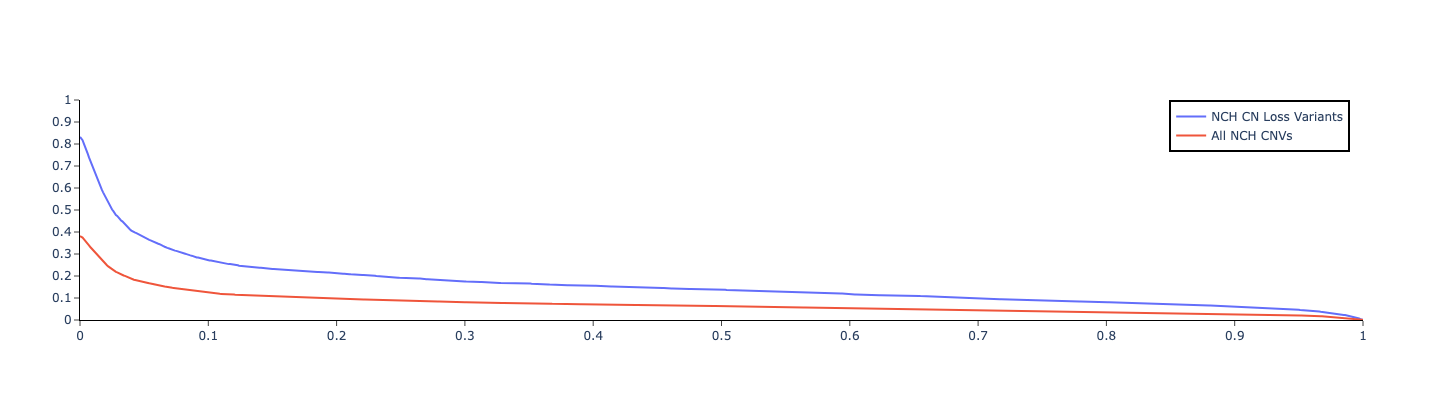

In [112]:
thrs = list(np.arange(0, 1.001, 0.001))
match_fractions_total = []
match_fractions_loss = []
for thr in thrs:
    if thr == 1: # handle edge case at maximum value of Jaccard score
        op = "=="
    else:
        op = ">="
    n_matches = nch_clinvar_hi_match_df.query(f"jaccard_score_bp_overlap {op} {thr}")['variant'].nunique()
    match_fractions_loss.append(n_matches / len(nch_df_loss))
    match_fractions_total.append(n_matches / len(nch_df))

fig = go.Figure()
fig.add_trace(go.Scatter(
    name="NCH CN Loss Variants", x=thrs, y=match_fractions_loss
))
fig.add_trace(go.Scatter(
    name="All NCH CNVs", x=thrs, y=match_fractions_total
))
fig.update_xaxes(linecolor='black', ticks='outside', dtick=0.1, range=[0,1])
fig.update_yaxes(linecolor='black', ticks='outside', dtick=0.1, range=[0,1])
fig.update_layout(
    height=400,
    width=600,
    plot_bgcolor='white',
    legend=dict(
        bordercolor='black',
        borderwidth=2,
        x=0.99,
        xanchor='right'
    )
)
fig.show()

## Matching NCH copy gain CNVs to ClinVar triplosensitivity overlapping variants

In [113]:
# get NCH copy gain CNVs
nch_df_gain = nch_df.query("copy_number_min > 2")
len(nch_df_gain)

4261

In [114]:
#get copy gain ClinVar CNVs
clinvar_df_gain = clinvar_df.query("absolute_copies > 2") 
len(clinvar_df_gain)

19330

In [115]:
# cross reference with all TS features
clinvar_ts_df = (
    clinvar_df_gain
    .merge( 
        right=feat_df_ts,
        how='inner',
        left_on='chr',
        right_on='chromosome',
        suffixes=('__clinvar', '__ts')
    )
)
len(clinvar_ts_df)

25191

In [118]:
# only keep total overlap with TS region
clinvar_ts_df = (
    clinvar_ts_df
    .query("start_38 <= genomic_start")
    .query("stop_38 >= genomic_stop")
)
len(clinvar_ts_df)

950

In [119]:
clinvar_df_ts_overlap = pd.DataFrame(
    clinvar_ts_df
    .groupby(clinvar_df.columns.to_list())
    ['feature_name']
    .nunique()
    .reset_index()
)
len(clinvar_df_ts_overlap)

554

In [120]:
nch_clinvar_ts_match_df = (
    nch_df_gain.merge(
        right=clinvar_df_ts_overlap,
        left_on='chromosome',
        right_on='chr',
        suffixes=('__nch', '__clinvar'),
        how='inner'
    )
    
)
nch_clinvar_ts_match_df = (
    nch_clinvar_ts_match_df
    .query(overlap_or_query)
)

len(nch_clinvar_ts_match_df)

30359

In [121]:
nch_clinvar_ts_match_df['start_outer'] = nch_clinvar_ts_match_df[
    ['start_38__nch', 'start_38__clinvar']
    ].min(axis=1)

nch_clinvar_ts_match_df['start_inner'] = nch_clinvar_ts_match_df[
    ['start_38__nch', 'start_38__clinvar']
    ].max(axis=1)

nch_clinvar_ts_match_df['stop_inner'] = nch_clinvar_ts_match_df[
    ['stop_38__nch', 'stop_38__clinvar']
    ].min(axis=1)

nch_clinvar_ts_match_df['stop_outer'] = nch_clinvar_ts_match_df[
    ['stop_38__nch', 'stop_38__clinvar']
    ].max(axis=1)

nch_clinvar_ts_match_df['jaccard_score_bp_overlap'] = (
    (nch_clinvar_ts_match_df['stop_inner'] - nch_clinvar_ts_match_df['start_inner'])
    / (nch_clinvar_ts_match_df['stop_outer'] - nch_clinvar_ts_match_df['start_outer'])
)

nch_clinvar_ts_match_df['jaccard_score_bp_overlap1'] = (
    nch_clinvar_ts_match_df
    [['start_38__nch', 'start_38__clinvar', 'stop_38__nch', 'stop_38__clinvar']]
    .apply(
        lambda row: 
        (sorted(row.values)[2] - sorted(row.values)[1])
        / (sorted(row.values)[3] - sorted(row.values)[0]),
        axis=1
    )
    
)

### Figure: Varying Jaccard BP Overlap Score, how many CN gain variants in NCH dataset have a ClinVar match containing a Triplosensitivity region/gene?

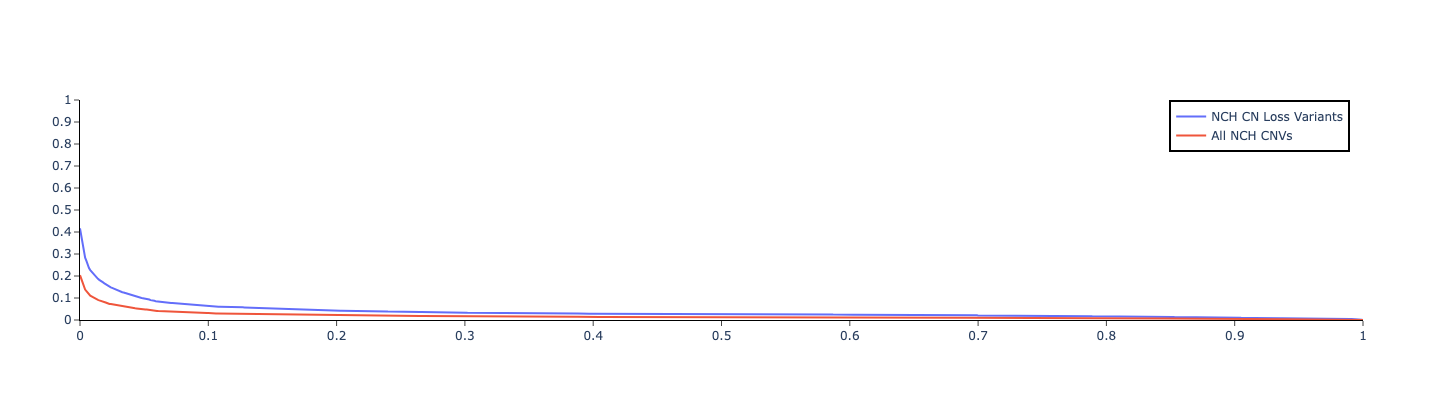

In [123]:
thrs = list(np.arange(0, 1.001, 0.001))
match_fractions_total = []
match_fractions_gain = []
for thr in thrs:
    if thr == 1: # handle edge case at maximum value of Jaccard score
        op = "=="
    else:
        op = ">="
    n_matches = nch_clinvar_ts_match_df.query(f"jaccard_score_bp_overlap {op} {thr}")['variant'].nunique()
    match_fractions_gain.append(n_matches / len(nch_df_gain))
    match_fractions_total.append(n_matches / len(nch_df))

fig = go.Figure()
fig.add_trace(go.Scatter(
    name="NCH CN Loss Variants", x=thrs, y=match_fractions_gain
))
fig.add_trace(go.Scatter(
    name="All NCH CNVs", x=thrs, y=match_fractions_total
))
fig.update_xaxes(linecolor='black', ticks='outside', dtick=0.1, range=[0,1])
fig.update_yaxes(linecolor='black', ticks='outside', dtick=0.1, range=[0,1])
fig.update_layout(
    height=400,
    width=600,
    plot_bgcolor='white',
    legend=dict(
        bordercolor='black',
        borderwidth=2,
        x=0.99,
        xanchor='right'
    )
)
fig.show()